# World-generation time across Minecraft versions

Runs the `WorldGeneration` workload against a freshly-started server and
measures how long it takes to generate fresh terrain -- compared across three
vanilla Minecraft versions to contrast **old vs new terrain generation**:

| Version | Image (Java) | Terrain generation |
|---------|--------------|--------------------|
| `1.17.1` | itzg `:java17` | old (last before the 1.18 overhaul) |
| `1.18.2` | itzg `:java17` | new (the Caves & Cliffs density-function gen) |
| `1.21.11` | itzg `:java25` | new (latest; 384-tall world) |

All three expose server tick times over JMX (the
`net.minecraft.server:type=Server` `tickTimes` MBean, present since 1.16), so
the per-tick collector works identically across them.

**Why not 1.16.5?** The bundled Jolokia agent is compiled for Java 17, so every
server must run on Java >=17. 1.16.x needs Java <=16, so it can't load the agent
-- making `1.17.1` the only old-gen version we can instrument.

**Structure** -- each version has its **own run cell** that leases two DAS nodes,
runs that version, and releases them, so each gets a fresh 15-minute reservation
(three versions don't fit in one). Trade-off: each version may land on different
hardware -- DAS nodes of a type are near-identical, but it's not the same-node
guarantee a single shared lease would give. InfluxDB runs persistently on the
headnode (its own cell; data on a bind mount); the plot cells read the
per-version DataFrames captured into `results`, each time-windowed to its run so
older data in the shared bucket can't leak in.

## Setup

Imports and experiment parameters.

In [2]:
# Auto-reload edited yardstick_benchmark modules without restarting the kernel.
%load_ext autoreload
%autoreload 2

import socket
import warnings
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

import yardstick_benchmark
from yardstick_benchmark.games.minecraft.server import (
    MinecraftServer,
    MinecraftServerCrashed,
)
from yardstick_benchmark.games.minecraft.workload import WorldGeneration
from yardstick_benchmark.model import Node
from yardstick_benchmark.monitoring import InfluxDB, InfluxDBInfo, Telegraf
from yardstick_benchmark.provisioning import Das
from yardstick_benchmark.util import wait_for_url

from _lib import query_influxdb_dataframe

# Our Flux queries return long-format, single-field data and don't pivot();
# silence influxdb-client's benign performance hint about it.
from influxdb_client.client.warnings import MissingPivotFunction
warnings.simplefilter("ignore", MissingPivotFunction)

# InfluxDB runs persistently on the headnode (where this kernel runs). The
# orchestrator reaches it at localhost; a remote workload/Telegraf must use a
# routable name, so resolve the headnode hostname here. A fixed admin token
# (rather than a random one) lets the run/cleanup cells reconnect to an
# already-running InfluxDB even across a kernel restart.
HEADNODE_NODE = Node("localhost", Path("/tmp/ysat-worldgen"))
HEADNODE_HOST = socket.gethostname()
INFLUX_TOKEN = "yardstick-dev-token"

# Vanilla versions to compare. The bundled Jolokia agent is compiled for Java
# 17, so every server must run on Java >=17 -- which rules out 1.16.x (needs
# Java <=16). That leaves 1.17.1 as the only OLD-gen version we can instrument;
# 1.18.2 and 1.21.11 are NEW-gen (the 1.18 overhaul, then latest). Each needs an
# itzg image with a compatible Java; all expose the tickTimes JMX MBean (>=1.16).
GAME_VERSIONS = [
    {"label": "1.17.1", "version": "1.17.1",
     "image": "docker://itzg/minecraft-server:java17"},   # old terrain gen
    {"label": "1.18.2", "version": "1.18.2",
     "image": "docker://itzg/minecraft-server:java17"},   # new gen (1.18 overhaul)
    {"label": "1.21.11", "version": "1.21.11",
     "image": "docker://itzg/minecraft-server:java25"},   # new gen (latest)
]

# Teleports per player. Each can take up to chunk_load_timeout (30s) on a slow
# new-gen version, so 32 * 30s ~ 16 min worst case -- lower this if a single
# version's run overruns its 15-minute lease.
TELEPORTS = 16
# Server render distance; chunks generated per teleport scale ~quadratically
# with this (itzg default is 10), so 6 keeps generation cheap enough to finish.
VIEW_DISTANCE = 6
# Player counts to sweep per version; one workload run per value.
PLAYER_COUNTS = (1,)

# Per-version captured DataFrames, keyed by version label. Each run cell fills
# (and overwrites) its own entry; `combine` stacks one metric across versions,
# tagging rows by version. Survives across run cells in one kernel session.
results = {}


def combine(key):
    frames = []
    for label, r in results.items():
        df = r.get(key)
        if df is None or len(df) == 0:
            continue
        df = df.copy()
        df["version"] = label
        frames.append(df)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Start InfluxDB (run once)

Starts InfluxDB on the headnode if it isn't already running. Safe to re-run --
it skips startup when InfluxDB is already healthy. Its data lives on a
bind-mounted host dir, so stopping and restarting the container keeps the data;
only the cleanup cell at the bottom deletes it.

In [3]:
influxdb = InfluxDB(HEADNODE_NODE, admin_token=INFLUX_TOKEN)
try:
    wait_for_url(f"{influxdb.url}/health", timeout_s=3)
    print(f"InfluxDB already running at {influxdb.url}")
except TimeoutError:
    print("InfluxDB not running; starting it...")
    influxdb.deploy()
    influxdb.start()
    wait_for_url(f"{influxdb.url}/health", timeout_s=60)
    print(f"InfluxDB started at {influxdb.url}")

# Connection info for the remote workload + Telegraf (routable headnode host).
workload_influx_info = InfluxDBInfo(
    urls=[f"http://{HEADNODE_HOST}:8086"], token=INFLUX_TOKEN
)

InfluxDB already running at http://localhost:8086


## Experiment runner

`run_version(cfg)` leases two compute nodes, runs one version end to end, and
releases the nodes -- so each version cell below gets its own fresh reservation.
It captures that run's DataFrames into `results[label]` (overwriting on re-run),
each query time-windowed to this run so the shared bucket's older data is
excluded.

In [4]:
def _run_query(start, body):
    flux = f'from(bucket: "yardstick")\n  |> range(start: {start})\n  ' + body
    return query_influxdb_dataframe(influxdb, flux)


# Flux query bodies (no interpolation): everything after the range() filter.
_Q_SUMMARY = ('|> filter(fn: (r) => r._measurement == "minecraft_worldgen" and '
              'r._field == "total_duration_ms")\n'
              '  |> keep(columns: ["_time", "_value", "player", "bots"])\n'
              '  |> group()')
_Q_TELEPORT = ('|> filter(fn: (r) => r._measurement == "minecraft_worldgen_teleport" '
               'and r._field == "load_ms")\n'
               '  |> keep(columns: ["_time", "_value", "player", "bots", "teleport"])\n'
               '  |> group()')
_Q_TICK = ('|> filter(fn: (r) => r._measurement == "minecraft_tick" and '
           'r._field == "tick_duration_ms")\n'
           '  |> keep(columns: ["_time", "_value"])\n  |> group()')
_Q_TPS = ('|> filter(fn: (r) => r._measurement == "minecraft_tick" and '
          'r._field == "tps")\n'
          '  |> keep(columns: ["_time", "_value"])\n  |> group()')
_Q_GC = ('|> filter(fn: (r) => r._measurement == "jvm_garbage_collector" and '
         'r._field == "CollectionTime")\n'
         '  |> group(columns: ["name"])\n'
         '  |> derivative(unit: 1s, nonNegative: true)\n'
         '  |> keep(columns: ["_time", "_value", "name"])\n  |> group()')


def run_version(cfg):
    """Lease 2 nodes, run one version, capture its data into results, release."""
    label = cfg["label"]
    das = Das()
    nodes = []
    try:
        nodes = das.provision(num=2, time_s=900)
        server_node, workload_node = nodes
        print(f"[{label}] server -> {server_node.host}, "
              f"workload -> {workload_node.host}")
        yardstick_benchmark.clean([server_node, workload_node])

        minecraft = MinecraftServer(
            "yardstick-worldgen-mc", node=server_node,
            version=cfg["version"], image_url=cfg["image"],
            view_distance=VIEW_DISTANCE,
        )
        telegraf = Telegraf(server_node, jolokia=True, execd_minecraft_ticks=True)
        telegraf.set_output_influxdb2(workload_influx_info)
        try:
            minecraft.start()
            minecraft.wait_until_ready()
            minecraft.set_world_spawn(0, 0)
            minecraft.start_health_monitor()
            telegraf.deploy()
            telegraf.start()

            v_start = datetime.now(timezone.utc)
            try:
                for bots in PLAYER_COUNTS:
                    print(f"[{label}] running WorldGeneration ({bots} player(s))...")
                    workload = WorldGeneration(
                        workload_node, server_node.host, workload_influx_info,
                        minecraft.rcon_password, bots_per_node=bots,
                        teleports=TELEPORTS, minecraft_version=cfg["version"],
                    )
                    workload.deploy()
                    try:
                        workload.run(health_check=minecraft.assert_healthy)
                        print(f"[{label}]   {bots}-player run done.")
                    finally:
                        workload.cleanup()
            except MinecraftServerCrashed as e:
                print(f"[{label}] !! aborted: server crashed: "
                      f"{e}".splitlines()[0])
                print(f"[{label}] !! keeping partial data from before the crash.")

            start = v_start.isoformat()
            results[label] = {
                "summary": _run_query(start, _Q_SUMMARY),
                "teleport": _run_query(start, _Q_TELEPORT),
                "tick": _run_query(start, _Q_TICK),
                "tps": _run_query(start, _Q_TPS),
                "gc": _run_query(start, _Q_GC),
            }
            print(f"[{label}] captured {len(results[label]['teleport'])} teleport, "
                  f"{len(results[label]['tick'])} tick points")
        finally:
            minecraft.stop_health_monitor()
            for nm, comp in (("telegraf", telegraf), ("minecraft", minecraft)):
                try:
                    comp.stop()
                except Exception as e:
                    print(f"[{label}] warning: {nm}.stop() failed: {e}")
    finally:
        if nodes:
            das.release(nodes)
            print(f"[{label}] released nodes")

## Run 1.17.1 (old terrain gen)

In [5]:
run_version(GAME_VERSIONS[0])

[1.17.1] server -> node034, workload -> node035
[1.17.1] running WorldGeneration (1 player(s))...


INFO:    Using cached SIF image


worldgen: started at 1781218051.114 - 1 player(s) on node 0, 16 teleports each, 1 player(s) total.
worldgen: launching player N0B0 (global 0)
N0B0: teleport 1/16 to (2000, 200, 0) [dist 2000] loaded in 458ms
N0B0: teleport 2/16 to (3500, 200, 0) [dist 3500] loaded in 1149ms
N0B0: teleport 3/16 to (5000, 200, 0) [dist 5000] loaded in 3258ms
N0B0: teleport 4/16 to (6500, 200, 0) [dist 6500] loaded in 977ms
N0B0: teleport 5/16 to (8000, 200, 0) [dist 8000] loaded in 1095ms
N0B0: teleport 6/16 to (9500, 200, 0) [dist 9500] loaded in 22536ms
N0B0: teleport 7/16 to (11000, 200, 0) [dist 11000] loaded in 16530ms
N0B0: teleport 8/16 to (12500, 200, 0) [dist 12500] loaded in 24170ms
N0B0: teleport 9/16 to (14000, 200, 0) [dist 14000] loaded in 20079ms
N0B0: teleport 10/16 to (15500, 200, 0) [dist 15500] loaded in 15306ms
N0B0: teleport 11/16 to (17000, 200, 0) [dist 17000] loaded in 22920ms
N0B0: teleport 12/16 to (18500, 200, 0) [dist 18500] loaded in 23017ms
N0B0: teleport 13/16 to (20000, 20

## Run 1.18.2 (new terrain gen)

In [7]:
run_version(GAME_VERSIONS[1])

[1.18.2] server -> node034, workload -> node035
[1.18.2] running WorldGeneration (1 player(s))...


INFO:    Using cached SIF image


worldgen: started at 1781218431.331 - 1 player(s) on node 0, 16 teleports each, 1 player(s) total.
worldgen: launching player N0B0 (global 0)
N0B0: teleport 1/16 to (2000, 200, 0) [dist 2000] loaded in 19811ms
N0B0: teleport 2/16 to (3500, 200, 0) [dist 3500] loaded in 2771ms
N0B0: teleport 3/16 to (5000, 200, 0) [dist 5000] loaded in 5795ms
N0B0: teleport 4/16 to (6500, 200, 0) [dist 6500] loaded in 2773ms
N0B0: teleport 5/16 to (8000, 200, 0) [dist 8000] loaded in 3902ms
N0B0: teleport 6/16 to (9500, 200, 0) [dist 9500] loaded in 13174ms
Error: client timed out after 30000 milliseconds
    at Timeout._onTimeout (/opt/workload/node_modules/minecraft-protocol/src/client/keepalive.js:18:28)
    at listOnTimeout (node:internal/timers:585:17)
    at process.processTimers (node:internal/timers:521:7)
Error: client timed out after 30000 milliseconds
    at Timeout._onTimeout (/opt/workload/node_modules/minecraft-protocol/src/client/keepalive.js:18:28)
    at listOnTimeout (node:internal/tim

## Run 1.21.11 (new terrain gen, latest)

In [8]:
run_version(GAME_VERSIONS[2])

[1.21.11] server -> node034, workload -> node035
[1.21.11] running WorldGeneration (1 player(s))...


INFO:    Using cached SIF image


worldgen: started at 1781218583.748 - 1 player(s) on node 0, 16 teleports each, 1 player(s) total.
worldgen: launching player N0B0 (global 0)
N0B0: teleport 1/16 to (2000, 200, 0) [dist 2000] loaded in 1480ms
N0B0: teleport 2/16 to (3500, 200, 0) [dist 3500] loaded in 30006ms (TIMEOUT)
N0B0: bot disconnected mid-run (socketClosed)
N0B0: teleport 3/16 to (5000, 200, 0) [dist 5000] loaded in 50597ms (TIMEOUT)
N0B0: aborting after 3/16 teleports -- bot disconnected
N0B0: done. 3/16 teleports in 82083ms (mean 27361ms, max 50597ms).
worldgen: finished (complete).
[1.21.11]   1-player run done.
[1.21.11] captured 3 teleport, 973 tick points
[1.21.11] released nodes


## World-generation time by version

Total time the player took to complete its teleport cycles, per version (lower
= faster generation). A version whose bot dropped early shows only its completed
portion. Run the version cells above first; replot any time -- it reads the
captured `results`, not InfluxDB.

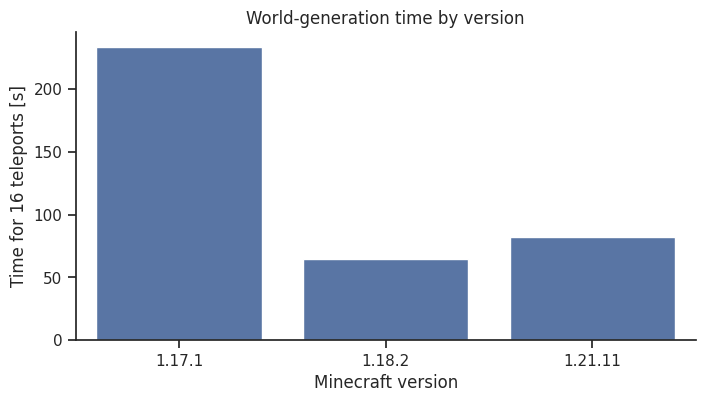

In [10]:
import seaborn as sns

sns.set_theme(style="ticks", context="notebook", font="DejaVu Sans")

s = combine("summary")
assert not s.empty, "no summary data -- run at least one version cell first"
s["total_s"] = s["_value"] / 1000.0

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=s, x="version", y="total_s", ax=ax)
ax.set_xlabel("Minecraft version")
ax.set_ylabel(f"Time for {TELEPORTS} teleports [s]")
ax.set_title("World-generation time by version")
ax.set_ylim(bottom=0)
sns.despine()
plt.show()

## Per-teleport world-generation latency

How long each teleport took to load in, by teleport index, one line per version.
Later teleports reach further-out terrain *and* run against more accumulated
loaded chunks, so the climb reflects both.

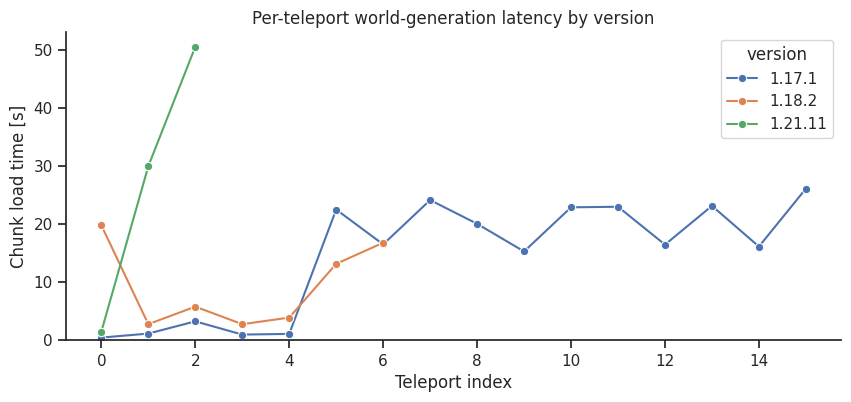

In [11]:
t = combine("teleport")
assert not t.empty, "no teleport data -- run at least one version cell first"
t["teleport"] = t["teleport"].astype(int)
t["load_s"] = t["_value"] / 1000.0

fig, ax = plt.subplots(figsize=(10, 4))
sns.lineplot(data=t, x="teleport", y="load_s", hue="version", marker="o", ax=ax)
ax.set_xlabel("Teleport index")
ax.set_ylabel("Chunk load time [s]")
ax.set_title("Per-teleport world-generation latency by version")
ax.set_ylim(bottom=0)
ax.legend(title="version")
sns.despine()
plt.show()

## Server tick time (MSPT)

Server main-thread time per tick (log scale), one line per version. Healthy is
~50 ms (20 TPS); spikes are world-generation stalls.

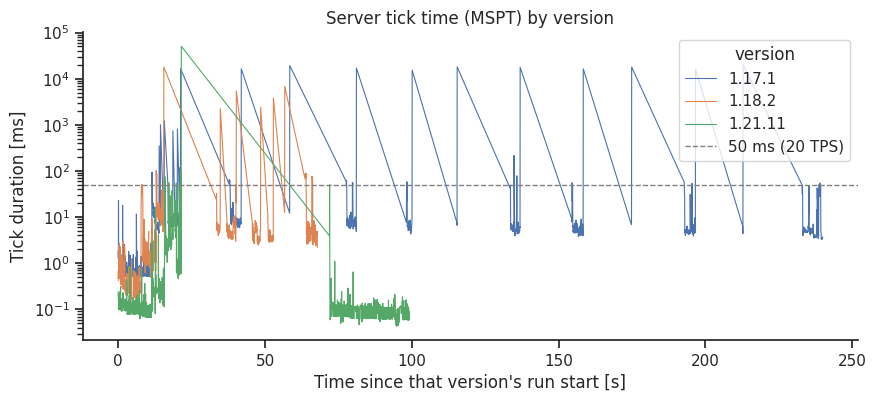

In [12]:
tk = combine("tick")
assert not tk.empty, "no tick data -- run at least one version cell first"
tk["t_s"] = tk.groupby("version")["_time"].transform(
    lambda x: (x - x.min()).dt.total_seconds()
)

fig, ax = plt.subplots(figsize=(10, 4))
sns.lineplot(data=tk, x="t_s", y="_value", hue="version", lw=0.8, ax=ax)
ax.axhline(50, ls="--", c="gray", lw=1, label="50 ms (20 TPS)")
ax.set_yscale("log")
ax.set_xlabel("Time since that version's run start [s]")
ax.set_ylabel("Tick duration [ms]")
ax.set_title("Server tick time (MSPT) by version")
ax.legend(title="version")
sns.despine()
plt.show()

## Server ticks per second

Ticks completed per wall-clock second (20 is the cap), one line per version.
Drops toward 0 during the generation stalls that freeze the main thread.

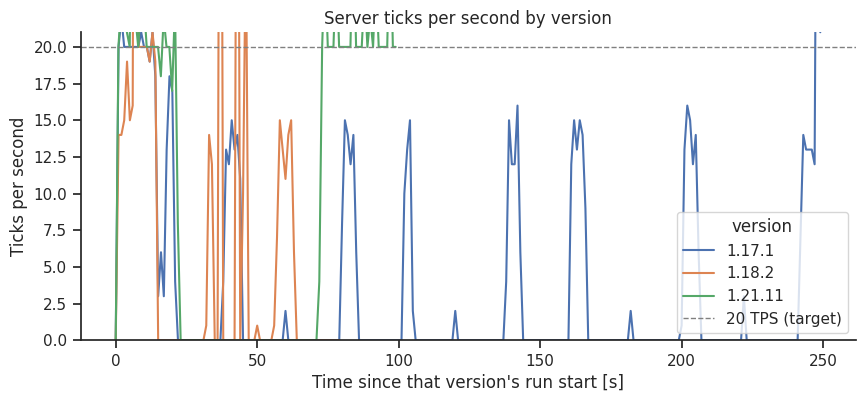

In [13]:
tp = combine("tps")
assert not tp.empty, "no tps data -- run at least one version cell first"
tp["t_s"] = tp.groupby("version")["_time"].transform(
    lambda x: (x - x.min()).dt.total_seconds()
)

fig, ax = plt.subplots(figsize=(10, 4))
sns.lineplot(data=tp, x="t_s", y="_value", hue="version", ax=ax)
ax.axhline(20, ls="--", c="gray", lw=1, label="20 TPS (target)")
ax.set_ylim(0, 21)
ax.set_xlabel("Time since that version's run start [s]")
ax.set_ylabel("Ticks per second")
ax.set_title("Server ticks per second by version")
ax.legend(title="version")
sns.despine()
plt.show()

## JVM garbage-collection time

Total GC time per wall-clock second (summed across collectors), one line per
version. 1000 ms/s = a full second spent in GC. A climb over the run is the
"accumulated loaded chunks" effect made visible -- watch whether the new-gen
versions differ from the old one.

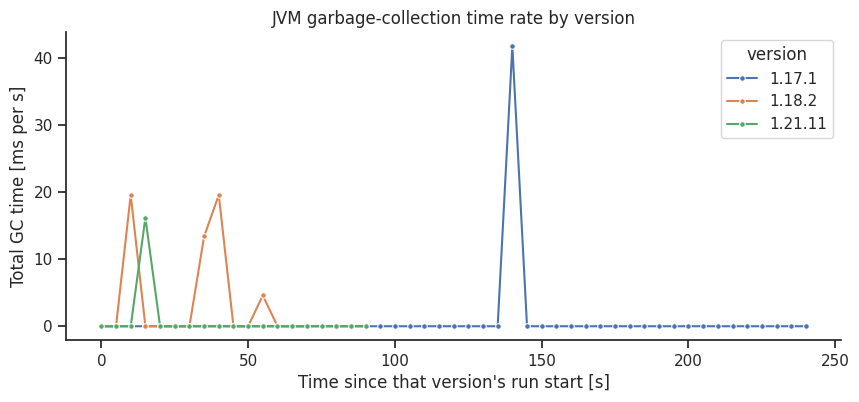

In [14]:
g = combine("gc")
assert not g.empty, "no gc data -- run at least one version cell first"
# Sum across collectors (young/old) per timestamp, per version.
g = g.groupby(["version", "_time"], as_index=False)["_value"].sum()
g["t_s"] = g.groupby("version")["_time"].transform(
    lambda x: (x - x.min()).dt.total_seconds()
)

fig, ax = plt.subplots(figsize=(10, 4))
sns.lineplot(data=g, x="t_s", y="_value", hue="version", marker="o", ms=4, ax=ax)
ax.set_xlabel("Time since that version's run start [s]")
ax.set_ylabel("Total GC time [ms per s]")
ax.set_title("JVM garbage-collection time rate by version")
ax.legend(title="version")
sns.despine()
plt.show()

## Cleanup -- stop & delete InfluxDB

Stops the InfluxDB container and deletes its bind-mounted data dir. Run this
when you're finished with all your runs. (Robust to a kernel restart -- it
rebuilds the handle from the same config if `influxdb` is gone.)

In [ ]:
try:
    _influx = influxdb
except NameError:
    # Kernel restarted since the start cell ran; rebuild the handle so we know
    # the instance name and data dir.
    _influx = InfluxDB(HEADNODE_NODE, admin_token=INFLUX_TOKEN)

try:
    _influx.stop()
    print("Stopped InfluxDB.")
except Exception as e:
    print(f"InfluxDB.stop() failed (maybe already stopped): {e}")

_influx.cleanup()
print(f"Deleted InfluxDB data dir: {_influx.data_dir}")